In [1]:
"""
DIA_Deep2SP_main_full_image.py

Differential Imaging Attack (DIA) on experimental Deep2SP+ with
a full-image camouflage objective.

Pipeline:
  1) Start from clean experimental NF-SAR measurements y_clean (complex).
  2) Inject complex attack gains A_p into a precomputed attack dictionary D_flat
     and add this to the clean victim measurements.
  3) Reconstruct the 3D image volume with Deep2SP+ (end-to-end DNN: y -> x).
  4) Optimize A (via a tanh-parameterization) so that the *entire* reconstructed
     3D magnitude image matches a “blank” target volume (camouflage).
"""
# ============================================================
# 0. Imports and basic setup
# ============================================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

import src  # for consistency with other Deep2S scripts (not used directly)

tf.random.set_seed(0)
np.random.seed(0)

In [2]:
# ============================================================
# 1. Load measurements and attack dictionary
# ============================================================

# --- 1.1 Load clean experimental measurements y_clean ---
# y_exp: (K, T, R), complex-valued NF-SAR measurements
y_clean_path = "data/y_exp_test_4.npy"   # <-- adjust path if needed
y_exp = np.load(y_clean_path)           # (K, T, R), complex or complex-like
y_exp = y_exp.astype(np.complex64)

# Add batch dimension so Deep2SP+ sees shape (N, K, T, R)
y_clean = y_exp[None, ...]              # (1, K, T, R)
print("y_clean.shape =", y_clean.shape)

# Infer dimensions
_, K, T, R = y_clean.shape
Np = T * R                               # number of per-aperture DOFs (attack DOF)

# --- 1.2 Flatten measurements to (K, Np) for attack injection ---
# For each aperture k, we stack (T, R) into a single Np-dimensional vector.
X_v_flat = y_clean[0].reshape(K, Np)     # (K, Np)
X_v_flat_tf = tf.constant(X_v_flat, dtype=tf.complex64)

print("Flattened victim measurements X_v_flat shape:", X_v_flat.shape)

# --- 1.3 Load precomputed attack dictionary D_flat ---
# D_flat is a pool of candidate attack waveforms, aligned and normalized.
D_flat_path = "data/D_flat.npy"          # <-- adjust path if needed
D_flat_np = np.load(D_flat_path)         # (K, Np), complex
assert D_flat_np.shape == X_v_flat.shape
D_flat_tf = tf.constant(D_flat_np.astype(np.complex64))

print("Loaded D_flat:", D_flat_np.shape)
print("y_clean.shape   =", y_clean.shape)
print("X_v_flat.shape  =", X_v_flat.shape)
print("D_flat.shape    =", D_flat_tf.shape)
print("Np (attack DOF) =", Np)

# TensorFlow constants used in the attack loop
y_clean_tf = tf.constant(y_clean)        # (1, K, T, R), complex64

y_clean.shape = (1, 15, 16, 9)
Flattened victim measurements X_v_flat shape: (15, 144)
Loaded D_flat: (15, 144)
y_clean.shape   = (1, 15, 16, 9)
X_v_flat.shape  = (15, 144)
D_flat.shape    = (15, 144)
Np (attack DOF) = 144


In [3]:
# ============================================================
# 2. Load Deep2SP+ DNN
# ============================================================

deep2sp_path = "models/experimental/Deep2S-Plus/model_Nf15_SNR30_Deep2SP_exp"
DNN = tf.keras.models.load_model(deep2sp_path, compile=False)
print("Loaded Deep2SP+ model from:", deep2sp_path)

Loaded Deep2SP+ model from: models/experimental/Deep2S-Plus/model_Nf15_SNR30_Deep2SP_exp


x_clean_mag.shape = (25, 25, 49)
x_clean_mag.shape = (25, 25, 49)


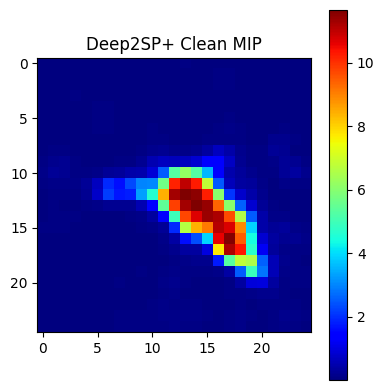

In [9]:
# ============================================================
# 3. Deep2SP+ forward operator: y -> DNN -> x_hat
# ============================================================

def deep2sp_forward_tf(y_batch: tf.Tensor) -> tf.Tensor:
    """
    Deep2SP+ forward mapping implemented in TensorFlow.

    Parameters
    ----------
    y_batch : tf.Tensor of shape (N, K, T, R), complex64
        Batch of complex-valued SAR measurements.

    Returns
    -------
    x_hat : tf.Tensor of shape (N, X, Y, Z), float32
        RMS-normalized reconstructed magnitude volumes.
    """
    # 1) Pack real and imaginary parts as 2 channels for Deep2SP+
    #    y_ri: (N, K, T, R, 2), float32
    y_ri = tf.stack(
        [tf.math.real(y_batch), tf.math.imag(y_batch)],
        axis=-1
    )

    # 2) Predict 3D volume with the Deep2SP+ network
    #    Output is (N, X, Y, Z, 1) or (N, X, Y, Z)
    x_hat = DNN(y_ri, training=False)

    # 3) Ensure real-valued output and remove trailing channel if present
    if tf.is_tensor(x_hat) and x_hat.dtype.is_complex:
        x_hat = tf.abs(x_hat)

    if len(x_hat.shape) == 5:
        x_hat = x_hat[..., 0]  # (N, X, Y, Z)

    # 4) RMS normalization: fix global scale to unit RMS per sample
    rms = tf.sqrt(
        tf.reduce_mean(x_hat**2, axis=(1, 2, 3), keepdims=True) + 1e-12
    )
    x_hat = x_hat / rms

    return x_hat  # (N, X, Y, Z), float32


# --- 3.1 Clean Deep2SP+ reconstruction (for reference) ---

x_clean_mag = deep2sp_forward_tf(y_clean_tf).numpy()[0]   # (X, Y, Z)
X, Y, Z = x_clean_mag.shape
print("x_clean_mag.shape =", x_clean_mag.shape)

# Quick 2D MIP visualization
clean_mip = x_clean_mag.max(axis=2)
plt.figure(figsize=(4, 4))
plt.imshow(clean_mip, origin="upper", cmap="jet")
plt.title("Deep2SP+ Clean MIP")
plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 4. Construct "blank" target volume (full-image camouflage)
# ============================================================

# We construct a "blank" background-like volume with mild random texture,
# normalized to unit RMS, which serves as the global camouflage target.

clean_mip = x_clean_mag.max(axis=2)
bg_val = float(clean_mip[0, 0])                     # reference background level
drange = float(clean_mip.max() - clean_mip.min())   # dynamic range

# Base background (constant over the full volume)
base = np.full((X, Y, Z), bg_val, dtype=np.float32)

# Add small random noise to avoid a perfectly flat target
np.random.seed(1234)
noise_std = 0.05 * drange
noise = noise_std * np.random.randn(X, Y, Z).astype(np.float32)

x_target = base + noise
x_target = np.clip(x_target, 0.0, None)             # enforce non-negativity

# Normalize target volume to unit RMS
rms_tgt = np.sqrt(np.mean(x_target**2) + 1e-12)
x_target = x_target / rms_tgt

x_target_tf = tf.constant(x_target[None, ...])      # (1, X, Y, Z)
x_target_mip = x_target.max(axis=2)

# Visualize clean vs target MIPs
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(clean_mip, origin="upper", cmap="jet")
plt.title("Clean Deep2SP+ MIP")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(x_target_mip, origin="upper", cmap="jet")
plt.title("Blank Target MIP")
plt.colorbar()

plt.tight_layout()
plt.show()

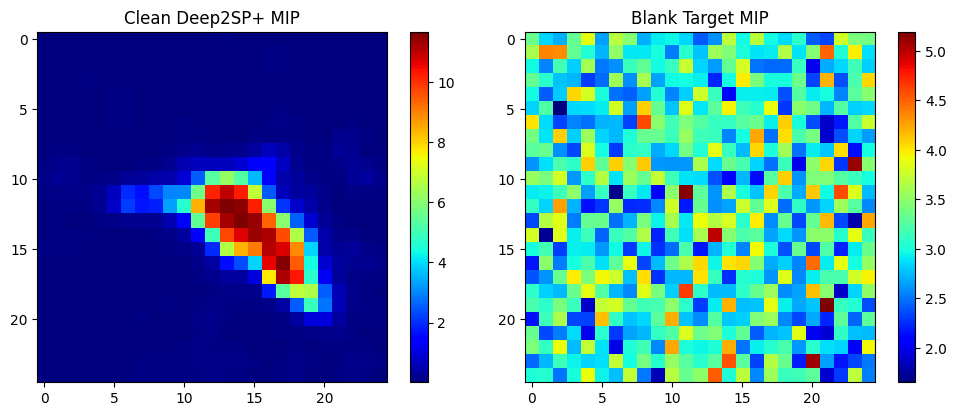

In [10]:
# ============================================================
# 5. Attack loss: full-image MSE + L2 on A
# ============================================================

def attack_loss(A_re: tf.Tensor, A_im: tf.Tensor, lambda_L2: float = 0.0):
    """
    Full-image DIA objective for Deep2SP+:

        L = MSE( x_att, x_target ) + lambda_L2 * ||A||_2^2

    where x_att is the Deep2SP+ reconstruction from attacked measurements.

    Parameters
    ----------
    A_re, A_im : tf.Tensor of shape (Np,)
        Real and imaginary parts of the complex attack gains A.
    lambda_L2 : float
        ℓ2 regularization weight on A (controls total attack energy).

    Returns
    -------
    loss      : scalar tf.Tensor
        Total objective (image MSE + regularization).
    mse_im    : scalar tf.Tensor
        Pure image-domain MSE term.
    reg       : scalar tf.Tensor
        ℓ2-regularization term on A.
    x_hat_mag : tf.Tensor of shape (1, X, Y, Z)
        Reconstructed attacked volume.
    """
    # Complex gains A_p (Np,)
    A_complex = tf.complex(A_re, A_im)
    A_col = tf.reshape(A_complex, (1, Np))          # (1, Np)

    # Attacked measurements (K, Np)
    # Each aperture's measurement vector is perturbed by D_flat * A.
    Y_flat = X_v_flat_tf + D_flat_tf * A_col        # (K, Np)

    # Reshape back to (1, K, T, R) for Deep2SP+
    Y_batch = tf.reshape(Y_flat, (1, K, T, R))      # (1, K, T, R)

    # Deep2SP+ reconstruction from attacked data
    x_hat_mag = deep2sp_forward_tf(Y_batch)         # (1, X, Y, Z)
    x_hat = x_hat_mag[0]                            # (X, Y, Z)
    x_tgt = x_target_tf[0]                          # (X, Y, Z)

    # Full-image mean-squared error
    diff = x_hat - x_tgt
    mse_im = tf.reduce_mean(diff**2)

    # ℓ2 regularization on A to discourage saturating all gains
    reg = lambda_L2 * tf.reduce_mean(tf.abs(A_complex)**2)

    loss = mse_im + reg
    return loss, mse_im, reg, x_hat_mag


In [28]:
# ============================================================
# 6. DIA loop with tanh-parameterized A (same style as Deep2S)
# ============================================================

Amax      = 2.0        # physical amplitude bound on |A_p|
lambda_L2 = 1e-5       # L2 weight (tune 1e-4–1e-2)
max_iter  = 300        # number of attack iterations

# Latent variables Z; A will be obtained via a tanh mapping
Z_re = tf.Variable(1e-3 * tf.random.normal(shape=(Np,), dtype=tf.float32))
Z_im = tf.Variable(1e-3 * tf.random.normal(shape=(Np,), dtype=tf.float32))

def get_A_from_Z(Z_re, Z_im, Amax=2.0):
    """
    Smooth parameterization:

        A_re = (Amax / sqrt(2)) * tanh(Z_re)
        A_im = (Amax / sqrt(2)) * tanh(Z_im)

    so that each component lies in [-Amax/sqrt(2), Amax/sqrt(2)],
    which guarantees |A_p| <= Amax without hard projection.
    """
    scale = Amax / np.sqrt(2.0)
    A_re = scale * tf.tanh(Z_re)
    A_im = scale * tf.tanh(Z_im)
    return A_re, A_im

# Adam with simple 2-stage learning-rate schedule
optimizer      = tf.keras.optimizers.Adam(learning_rate=9e-1)
lr_switch_iter = 100
low_lr         = 1e-2

loss_hist  = []
meanA_hist = []
maxA_hist  = []

print("\nStarting DIA optimization on Deep2SP+ (Np = {})...".format(Np))

for it in range(1, max_iter + 1):

    # Learning-rate schedule: high LR, then lower after lr_switch_iter
    if it == lr_switch_iter + 1:
        optimizer.learning_rate.assign(low_lr)
        print(f"\n[LR SCHEDULE] Switched Adam LR to {low_lr}\n")

    with tf.GradientTape() as tape:
        A_re_cur, A_im_cur = get_A_from_Z(Z_re, Z_im, Amax=Amax)
        loss_total, loss_im, reg, x_hat_mag = attack_loss(
            A_re_cur, A_im_cur, lambda_L2=lambda_L2
        )

    grads = tape.gradient(loss_total, [Z_re, Z_im])
    optimizer.apply_gradients(zip(grads, [Z_re, Z_im]))

    # Logging statistics
    A_re_val, A_im_val = get_A_from_Z(Z_re, Z_im, Amax=Amax)
    A_complex = tf.complex(A_re_val, A_im_val)
    A_now     = A_complex.numpy()
    meanA     = np.mean(np.abs(A_now))
    maxA      = np.max(np.abs(A_now))

    loss_hist.append(loss_total.numpy().item())
    meanA_hist.append(meanA)
    maxA_hist.append(maxA)

    if (it == 1) or (it % 5 == 0) or (it == max_iter):
        print(
            f"Iter {it:3d}/{max_iter:3d} | "
            f"Loss={loss_total.numpy():.6e} | "
            f"loss_im={loss_im.numpy():.6e} | reg={reg.numpy():.6e} | "
            f"mean|A|={meanA:.3e}, max|A|={maxA:.3e}"
        )

print("Attack optimization finished.")



Starting DIA optimization on Deep2SP+ (Np = 144)...
Iter   1/300 | Loss=1.776487e+00 | loss_im=1.776487e+00 | reg=4.099377e-11 | mean|A|=1.417e+00, max|A|=1.433e+00
Iter   5/300 | Loss=9.739624e-01 | loss_im=9.739301e-01 | reg=3.222947e-05 | mean|A|=1.846e+00, max|A|=1.998e+00
Iter  10/300 | Loss=9.335427e-01 | loss_im=9.335048e-01 | reg=3.791093e-05 | mean|A|=1.947e+00, max|A|=2.000e+00
Iter  15/300 | Loss=9.292194e-01 | loss_im=9.291807e-01 | reg=3.859990e-05 | mean|A|=1.961e+00, max|A|=2.000e+00
Iter  20/300 | Loss=9.274677e-01 | loss_im=9.274287e-01 | reg=3.903285e-05 | mean|A|=1.975e+00, max|A|=2.000e+00
Iter  25/300 | Loss=9.268565e-01 | loss_im=9.268171e-01 | reg=3.933925e-05 | mean|A|=1.983e+00, max|A|=2.000e+00
Iter  30/300 | Loss=9.265692e-01 | loss_im=9.265298e-01 | reg=3.934664e-05 | mean|A|=1.982e+00, max|A|=2.000e+00
Iter  35/300 | Loss=9.265441e-01 | loss_im=9.265049e-01 | reg=3.929045e-05 | mean|A|=1.979e+00, max|A|=2.000e+00
Iter  40/300 | Loss=9.258887e-01 | loss_im=

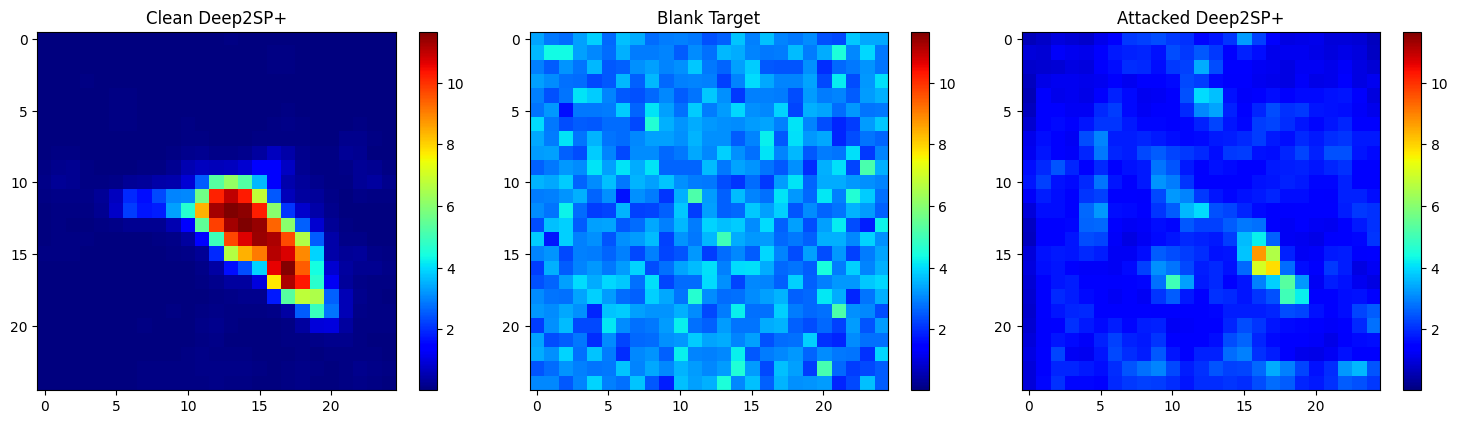

In [29]:
# ============================================================
# 7. Final attacked reconstruction and visualization
# ============================================================

# Get final optimized A from the latent variables Z_re, Z_im
A_re_opt, A_im_opt = get_A_from_Z(Z_re, Z_im, Amax=Amax)   # (Np,), (Np,)
A_opt_tf = tf.complex(A_re_opt, A_im_opt)                  # (Np,)
A_opt_col = tf.reshape(A_opt_tf, (1, Np))                  # (1, Np)

# Build attacked measurements
Y_opt_flat_tf = X_v_flat_tf + D_flat_tf * A_opt_col        # (K, Np)
Y_opt_tf = tf.reshape(Y_opt_flat_tf, (1, K, T, R))         # (1, K, T, R)

# Run Deep2SP+ forward on attacked data
x_att_mag = deep2sp_forward_tf(Y_opt_tf).numpy()[0]        # (X, Y, Z)

# 2D Maximum Intensity Projections (MIP) over depth z
clean_mip = x_clean_mag.max(axis=2)
att_mip = x_att_mag.max(axis=2)
target_mip = x_target.max(axis=2)

vmin = clean_mip.min()
vmax = clean_mip.max()

plt.figure(figsize=(15, 4))

# 1) Clean MIP
plt.subplot(1, 3, 1)
plt.imshow(clean_mip, origin="upper", cmap="jet", vmin=vmin, vmax=vmax)
plt.title("Clean Deep2SP+")
plt.colorbar()

# 2) Blank target MIP
plt.subplot(1, 3, 2)
plt.imshow(target_mip, origin="upper", cmap="jet", vmin=vmin, vmax=vmax)
plt.title("Blank Target")
plt.colorbar()

# 3) Attacked MIP
plt.subplot(1, 3, 3)
plt.imshow(att_mip, origin="upper", cmap="jet", vmin=vmin, vmax=vmax)
plt.title("Attacked Deep2SP+")
plt.colorbar()

plt.tight_layout()
plt.show()



--- MIP-level attack metrics (full image, Deep2SP+) ---
MSE   : 2.6089e+00
RMSE  : 1.6152e+00
MAE   : 1.4207e+00
NCC   : 0.9015
SSIM  : -0.0076
PSNR  : 6.81 dB


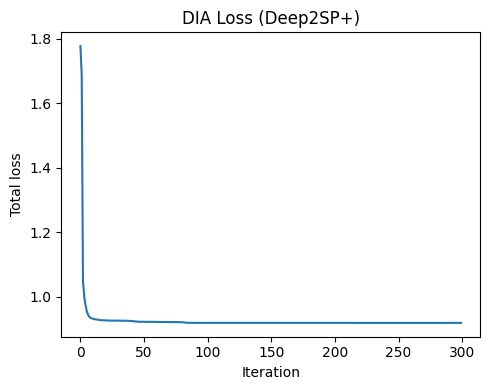

In [30]:
# ============================================================
# 8. Global MIP-level quantitative evaluation
# ============================================================

# Simple scalar image-quality metrics comparing MIPs of target vs attacked.
mse_mip = np.mean((att_mip - target_mip) ** 2)
rmse_mip = np.sqrt(mse_mip)
mae_mip = np.mean(np.abs(att_mip - target_mip))

num = np.sum(att_mip * target_mip)
den = np.sqrt(np.sum(att_mip**2) * np.sum(target_mip**2)) + 1e-12
ncc_mip = num / den

data_range = float(target_mip.max() - target_mip.min() + 1e-12)
ssim_mip = ssim(att_mip, target_mip, data_range=data_range)
psnr_mip = psnr(target_mip, att_mip, data_range=data_range)

print("\n--- MIP-level attack metrics (full image, Deep2SP+) ---")
print(f"MSE   : {mse_mip:.4e}")
print(f"RMSE  : {rmse_mip:.4e}")
print(f"MAE   : {mae_mip:.4e}")
print(f"NCC   : {ncc_mip:.4f}")
print(f"SSIM  : {ssim_mip:.4f}")
print(f"PSNR  : {psnr_mip:.2f} dB")

# Loss curve (for inspection)
plt.figure(figsize=(5, 4))
plt.plot(loss_hist)
plt.xlabel("Iteration")
plt.ylabel("Total loss")
plt.title("DIA Loss (Deep2SP+)")
plt.tight_layout()
plt.show()